In [1]:
import sys
sys.path.append('../')
import scqubits as scq
import pandas as pd
import qutip as qt
import numpy as np
from matplotlib import pyplot as plt
from qutip.qip.operations import rz, cz_gate
from tqdm import tqdm
from matplotlib.colors import LogNorm
import time, pytz, os, itertools, cmath
from datetime import datetime
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from joblib import Parallel, delayed
import scipy.sparse as ssp
from sympy import symbols
import scipy as sp
import utils_2Q_gate_zp as ut
from scipy.ndimage import gaussian_filter


In [ ]:
truc_one_qubit, truc_tot, charge_pick = 300, 1000, True
truc_full = 1000

[hspace_full, eket_tot, eval_tot, n_theta0_dress, 
    n_theta1_dress, hspace_0, hspace_1, logi_state
    ] = ut.load_qubit_data_2q(truc_one_qubit, truc_full, charge_pick)

A1_bound, A2_bound, detune1_bound, detune2_bound = [
    (0.001, 0.5), (0.001, 0.5), (-0.5, 0.5), (-0.5, 0.5)    ]
tg_bound = (-0.001, 0.001) #(-1e-10, 1e-10) #

max_step_ideal, max_step_noisy = 3e-4, 1e-3 # Set max_step to 0 for parallel execution
option_ideal, option_noisy = ut.get_qutip_options(max_step_ideal, max_step_noisy) 

workers, popsize = 100, 10
recombination, tol, mutation = [0.7, 0.01, (0.5, 1.0)]
logi_state = ['0-0', '0-2', '2-0', '2-2']
mid_state = '8-2'
idx_0 = hspace_full.index('0-2')
idx_1 = hspace_full.index('2-2')

hspace_part = logi_state + [mid_state] + ['1-4', '8-0'] # hspace_full[:200] # ut.truc_model['cnot_short_1000'][:200]

idx_2 = hspace_full.index(mid_state)
W_0_2 = eval_tot[idx_2] - eval_tot[idx_0]
W_1_2 = eval_tot[idx_2] - eval_tot[idx_1]
H0_full = qt.Qobj(np.diag(eval_tot))

index_part = [hspace_full.index(i) for i in hspace_part]
len_part = len(hspace_part)
H0_part = ut.truncate_2( H0_full, index_part)
n_theta0_part = ut.truncate_2(n_theta0_dress, index_part)
n_theta1_part = ut.truncate_2(n_theta1_dress, index_part)
logi_idx_part = [hspace_part.index(i) for i in logi_state]

state_full = [qt.basis(len_part, i) for i in range(len_part)]
H_drive_part = [ H0_part,   [n_theta0_part, ut.drive_gauss_A],
                            [n_theta0_part, ut.drive_gauss_B]  ]

c_op_list = []
num_cpus = 200
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [25.020473,0.180208,0.046132,-0.003789,0.001544 ] 
# cnot
# [100.006167,0.053076,0.029316,-0.01188,-0.01157]
# [340.0063,0.016618,0.010608,-0.001774,-0.00169]
# x-gate
# [10.108462,0.41212,0.073451,-0.084451,-0.044706 ]
# [25.020473,0.180208,0.046132,-0.003789,0.001544 ] 
# [119.917464,0.033248,0.00908,0.000489,0.000672]
 
arg_optimize = [tg, drive_amp_A, drive_amp_B, detune_A, detune_B]
pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': W_0_2 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': W_1_2 + 2*np.pi*detune_B,
            'gate_time': tg }
tlist = np.linspace(0, tg, num=int(tg))  # total time
logi_state_one = [0,2]

In [32]:
# Population in select
result = {}
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in tqdm(enumerate(logi_state_one)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_drive_part,
            qt.basis(len_part, hspace_part.index( str(state_i) +'-'+str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_full],
            args=pulse_args,
            options=qt.Options(store_states=True, num_cpus=num_cpus, nsteps=10000) )

2it [00:00, 27.51it/s]
2it [00:00, 25.94it/s]


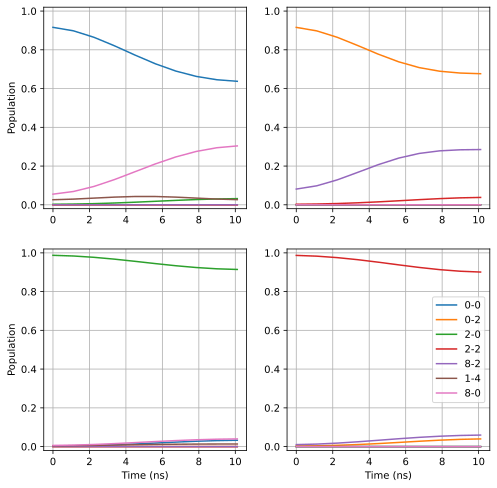

In [33]:
fig, ax = plt.subplots(figsize=(8,8), nrows=2, ncols=2)
# fig.suptitle(f"CNOT (tg={tg:.0f}, $|8,2\\rangle$, logF={fidelity_full:.3f}, $N_{{\\rm state}}$={truc1})", fontsize=16, y=0.92)
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in enumerate(logi_state_one):
        for kdx, res in zip(hspace_part, result[idx,jdx].expect):
            y_pop = gaussian_filter( np.array(res).flatten(), 3)
            # if np.max(y_pop) > 0.01:
            ax[idx][jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) ,  label=r"%s" %kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
ax[1][1].legend()


In [37]:
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [25.020473,0.180208,0.046132,-0.003789,0.001544 ] 
x0 = [tg, drive_amp_A, drive_amp_B, detune_A, detune_B]
# [tg, drive_amp_A, drive_amp_B, detune_A, detune_B]
# [25.020473,0.180208,0.046132,-0.003789,0.001544 ] 

tg_bound = (-0.01, 0.01) #(-1e-10, 1e-10) #
A1_bound, A2_bound, detune1_bound, detune2_bound = [
    (0.001, 0.5), (0.001, 0.5), (-0.5, 0.5), (-0.5, 0.5)     ]

workers, popsize = 100, 10
recombination, tol, mutation = [0.7, 0.01, (0.5, 1.0)]
num_cpus = 1

arg_truc = [H_drive_part, W_0_2, W_1_2, num_cpus, c_op_list, 
            logi_idx_part, mid_state, option_ideal, option_noisy]

tg_bounds = (tg+tg_bound[0], tg+tg_bound[1])
bounds = (tg_bounds, A1_bound, A2_bound, detune1_bound, detune2_bound)
res = sp.optimize.differential_evolution(
    func=ut.XI_fidelity_log_noise,
    bounds=bounds,
    args=arg_truc,
    disp=True,
    callback=ut.print_soln,
    init="sobol",
    workers=workers,
    popsize=popsize,
    mutation=mutation,
    recombination=recombination,
    tol=tol,
    x0=x0,
    polish=False, # 'True' will make the for-loop break
    )

print(res, '\n')



 /home/zlqed/anaconda3/envs/qutip4/lib/python3.11/site-packages/scipy/optimize/_differentialevolution.py: 387

differential_evolution step 1: f(x)= -0.0969144
Best Solution: [25.03022654, 0.30625751, 0.32852025, -0.00173454, 0.00035211]
Convergence: 1678.6903
----------------------------
 message: Optimization terminated successfully.
 success: True
     fun: -0.09691438647880377
       x: [ 2.503e+01  3.063e-01  3.285e-01 -1.735e-03  3.521e-04]
     nit: 1
    nfev: 128 

